# Sequential Models Practice

## Step 1 — Introduction

**Sequential Models Practice:**

In this notebook, we will explore recurrent neural networks using TensorFlow/Keras.

**Objectives:**

- Generate synthetic sequential data
- Convert sequences into supervised learning samples
- Build an LSTM model
- Build a GRU model
- Compare their performance
- Perform sequence pattern classification
- Visualize learned hidden representations

By the end of this notebook, you'll understand how recurrent neural networks process sequential data and how LSTMs and GRUs overcome the limitations of vanilla RNNs.

## Step 2 — Imports

In [5]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import Sequential, Input, Model
from tensorflow.keras.layers import LSTM, GRU, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

## Step 3 — Verify TensorFlow

In [6]:
print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:", gpus[0].name)
else:
    print("Running on CPU")

TensorFlow: 2.19.0
GPU detected: /physical_device:GPU:0


## Step 4 — Generate Synthetic Time Series

In [7]:
time = np.arange(0, 500)

signal = np.sin(0.04 * time)

noise = np.random.normal(scale=0.1, size=len(time))

series = signal + noise

## Step 5 — Visualize the Data

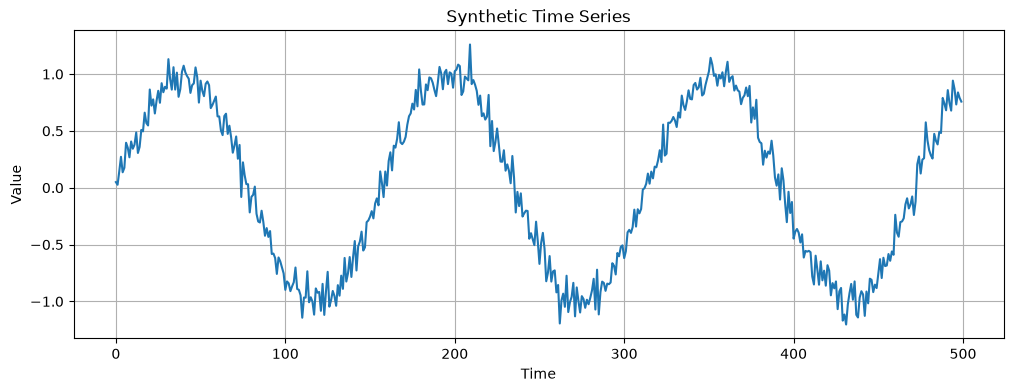

In [8]:
plt.figure(figsize=(12,4))

plt.plot(time, series)

plt.title("Synthetic Time Series")

plt.xlabel("Time")

plt.ylabel("Value")

plt.grid(True)

plt.show()

## Step 6 — Sliding Window Function

In [9]:
def create_sequences(data, window_size):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(data[i:i + window_size])

        y.append(data[i + window_size])

    return np.array(X), np.array(y)

## Step 7 — Create Input Sequences

**Create Sliding Windows:**

Neural networks cannot directly learn from a long continuous sequence. Instead, we divide the time series into smaller overlapping windows.

For example, with a window size of **20**, the model uses the previous 20 values to predict the next value.

Example:

Input:
```
[0.1, 0.2, 0.3, ..., 0.8]
```

Target:
```
0.9
```

This transforms the time series into a supervised learning problem.

In [10]:
WINDOW_SIZE = 20

X, y = create_sequences(series, WINDOW_SIZE)

print("Input shape :", X.shape)
print("Target shape:", y.shape)

Input shape : (480, 20)
Target shape: (480,)


## Step 8 — Train/Test Split

**Train-Test Split:**

We split the dataset into training and testing sets.

Since this is a time series problem, we **do not shuffle** the data. This preserves the chronological order and prevents information from the future leaking into the training set.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 384
Testing samples : 96


## Step 9 — Reshape for LSTM/GRU

**Reshape the Data:**

LSTM and GRU layers expect input with three dimensions:

```
(samples, timesteps, features)
```

- **Samples:** Number of sequences
- **Timesteps:** Length of each sequence (window size)
- **Features:** Number of variables at each time step

Since our synthetic data contains only one feature, the feature dimension is **1**.

In [12]:
X_train = X_train.reshape((-1, WINDOW_SIZE, 1))
X_test = X_test.reshape((-1, WINDOW_SIZE, 1))

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

Training shape: (384, 20, 1)
Testing shape : (96, 20, 1)


## Step 10 — Build the LSTM Model

**Build an LSTM Model:**

We use a simple LSTM network for time series regression.

Architecture:

Input (20 × 1)

↓

LSTM (64 units)

↓

Dense (32)

↓

Dense (1)

The final layer contains one neuron because we are predicting a single continuous value.

In [13]:
lstm_model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.summary()

I0000 00:00:1784636455.087301    4561 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1414 MB memory:  -> device: 0, name: NVIDIA GeForce MX330, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

## Step 11 — Compile the Model

In [14]:
lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 12 — Train the Model

In [15]:
history = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


I0000 00:00:1784636540.715585    4935 cuda_dnn.cc:529] Loaded cuDNN version 90300


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.3246 - mae: 0.5003 - val_loss: 0.1495 - val_mae: 0.3440
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0865 - mae: 0.2494 - val_loss: 0.0760 - val_mae: 0.2207
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0513 - mae: 0.1909 - val_loss: 0.0475 - val_mae: 0.1968
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0418 - mae: 0.1760 - val_loss: 0.0321 - val_mae: 0.1485
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0291 - mae: 0.1397 - val_loss: 0.0221 - val_mae: 0.1186
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0208 - mae: 0.1175 - val_loss: 0.0150 - val_mae: 0.0963
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0151 - mae: 0.0984 - val_loss: 0.0115 - val_mae: 0.0859
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0131 - mae: 0.0904 - val_loss: 0.0109 - val_mae: 0.0836
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0130 - mae: 0.

## Step 13 — Plot the Learning Curves
**Training Performance:**

We visualize the training and validation loss to monitor how well the model learns and to check for signs of overfitting.

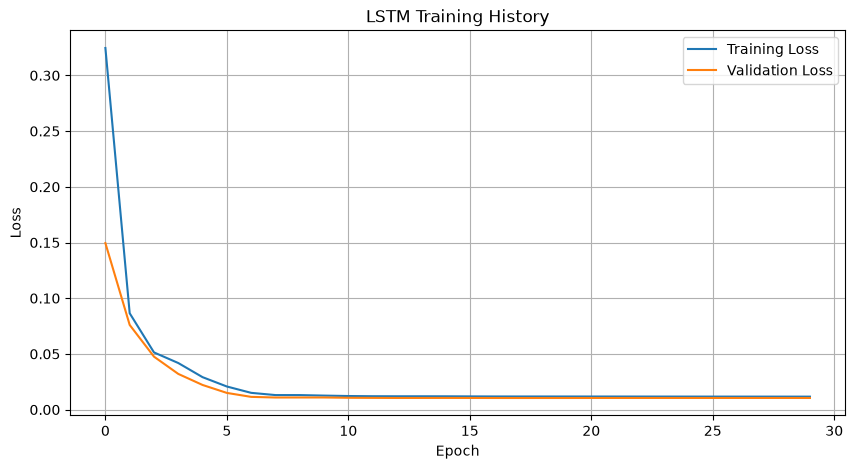

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")

plt.legend()
plt.grid(True)

plt.show()

## Step 14 — Make Predictions

In [17]:
y_pred = lstm_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


## Step 15 — Evaluate the Model

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"MSE : {mse:.4f}")
print(f"MAE : {mae:.4f}")

MSE : 0.0141
MAE : 0.0953


## Step 16 — Plot Actual vs Predicted

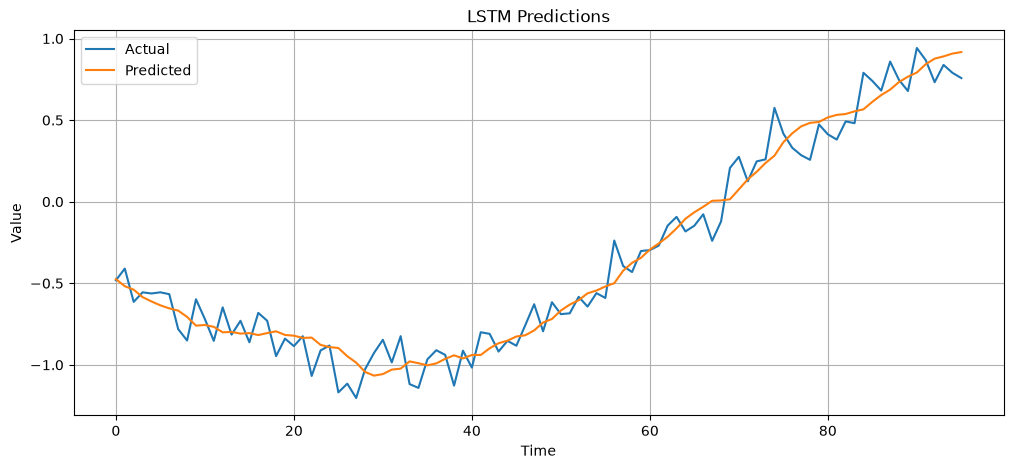

In [19]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.title("LSTM Predictions")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.show()

## Step 17 — Build a GRU Model
GRUs are a simplified version of LSTMs.

They typically:

- Train faster
- Use fewer parameters
- Achieve performance similar to LSTMs on many tasks

In [20]:
gru_model = Sequential([
    Input(shape=(WINDOW_SIZE, 1)),
    GRU(64),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

## Step 18 — Compile

In [21]:
gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

## Step 19 — Train

In [22]:
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.3448 - mae: 0.5155 - val_loss: 0.1849 - val_mae: 0.3828
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0991 - mae: 0.2633 - val_loss: 0.0227 - val_mae: 0.1223
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0310 - mae: 0.1393 - val_loss: 0.0305 - val_mae: 0.1359
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0235 - mae: 0.1245 - val_loss: 0.0190 - val_mae: 0.1106
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0210 - mae: 0.1182 - val_loss: 0.0183 - val_mae: 0.1081
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0192 - mae: 0.1104 - val_loss: 0.0166 - val_mae: 0.0966
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0185 - mae: 0.1082 - val_loss: 0.0158 - val_mae: 0.0949
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0178 - mae: 0.1071 - val_loss: 0.0153 - val_mae: 0.0942
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.017

## Step 20 — Predict

In [23]:
gru_pred = gru_model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


## Step 21 — Evaluate

In [24]:
gru_mse = mean_squared_error(y_test, gru_pred)
gru_mae = mean_absolute_error(y_test, gru_pred)

print(f"GRU MSE : {gru_mse:.4f}")
print(f"GRU MAE : {gru_mae:.4f}")

GRU MSE : 0.0147
GRU MAE : 0.0949


## Step 22 — Plot Predictions

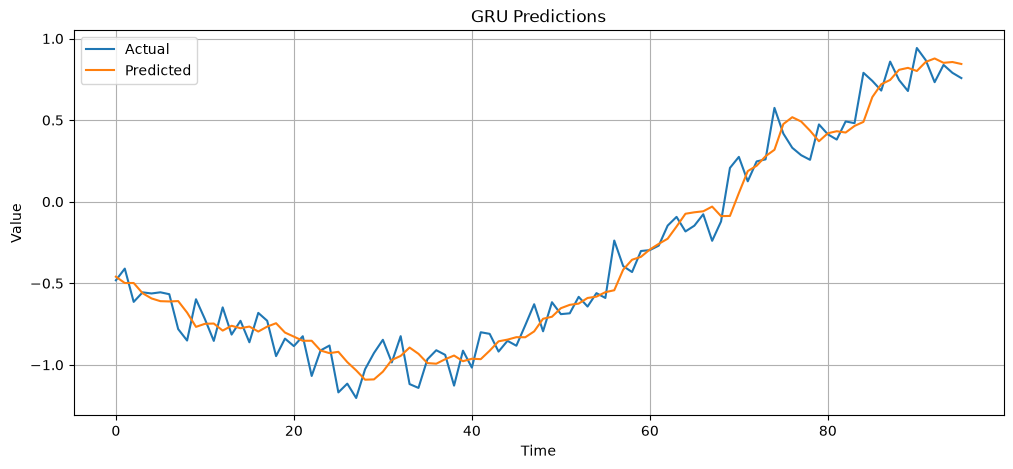

In [25]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label="Actual")
plt.plot(gru_pred, label="Predicted")

plt.title("GRU Predictions")
plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.show()

## Step 23 — Compare LSTM and GRU

In [26]:
comparison = pd.DataFrame({
    "Model": ["LSTM", "GRU"],
    "MSE": [mse, gru_mse],
    "MAE": [mae, gru_mae]
})

comparison

,Model,MSE,MAE
0,LSTM,0.014087,0.095273
1,GRU,0.014698,0.094949


## Step 24 — Plot Both Predictions Together

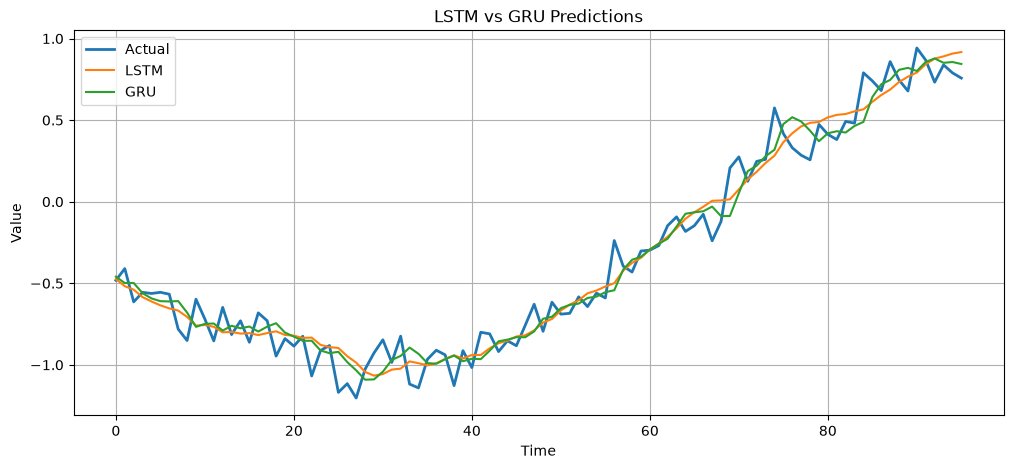

In [27]:
plt.figure(figsize=(12,5))

plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(y_pred, label="LSTM")
plt.plot(gru_pred, label="GRU")

plt.title("LSTM vs GRU Predictions")

plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()
plt.grid(True)

plt.show()

# Part 2 — Pattern Classification

## Step 25 — Generate Synthetic Sequences

**Pattern Classification:**

Recurrent neural networks can also classify entire sequences.

In this example, we generate three different sequence patterns:

- Increasing
- Decreasing
- Oscillating

The model will learn to recognize the pattern represented by each sequence.

In [28]:
def generate_sequences(n_samples=300, seq_len=20):

    X = []
    y = []

    # Increasing
    for _ in range(n_samples):
        start = np.random.uniform(0, 5)
        seq = start + np.arange(seq_len)
        seq += np.random.normal(0, 0.3, seq_len)

        X.append(seq)
        y.append(0)

    # Decreasing
    for _ in range(n_samples):
        start = np.random.uniform(20, 30)
        seq = start - np.arange(seq_len)
        seq += np.random.normal(0, 0.3, seq_len)

        X.append(seq)
        y.append(1)

    # Oscillating
    for _ in range(n_samples):
        seq = np.sin(np.linspace(0, 3*np.pi, seq_len))
        seq += np.random.normal(0, 0.2, seq_len)

        X.append(seq)
        y.append(2)

    return np.array(X), np.array(y)

## Step 26 — Create Dataset

In [29]:
X_cls, y_cls = generate_sequences()

print(X_cls.shape)
print(y_cls.shape)

(900, 20)
(900,)


## Step 27 — Visualize Examples

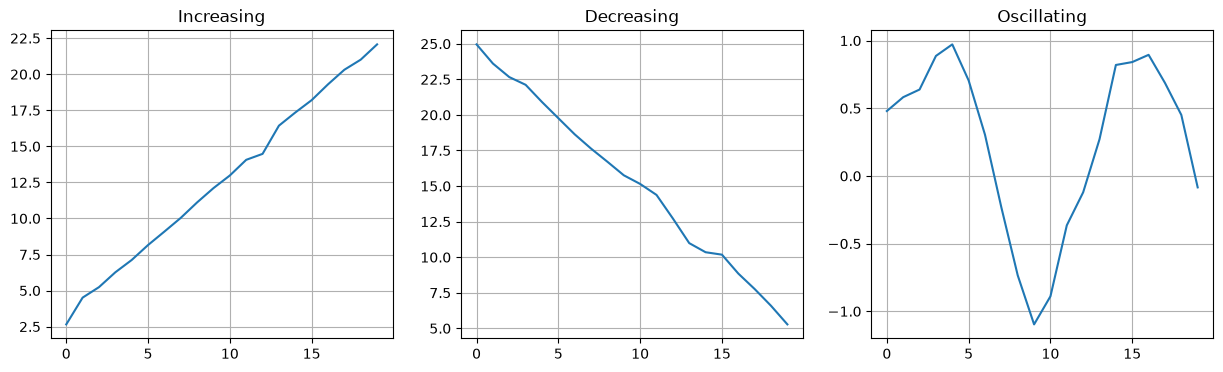

In [30]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

titles = ["Increasing","Decreasing","Oscillating"]

for i in range(3):
    axes[i].plot(X_cls[i*300])
    axes[i].set_title(titles[i])
    axes[i].grid(True)

plt.show()

## Step 28 — Train/Test Split

In [31]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

X_train_cls = X_train_cls.reshape((-1,20,1))
X_test_cls = X_test_cls.reshape((-1,20,1))

## Step 29 — Build Classification Model

In [32]:
classifier = Sequential([
    Input(shape=(20,1)),
    LSTM(64),
    Dense(32, activation="relu"),
    Dense(3, activation="softmax")
])

classifier.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,075 (74.51 KB)

 Trainable params: 19,075 (74.51 KB)

 Non-trainable params: 0 (0.00 B)

## Step 30 — Compile

In [33]:
classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Step 31 — Train

In [34]:
history_cls = classifier.fit(
    X_train_cls,
    y_train_cls,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7951 - loss: 0.7408 - val_accuracy: 1.0000 - val_loss: 0.5657
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.3472 - val_accuracy: 1.0000 - val_loss: 0.1734
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0553 - val_accuracy: 1.0000 - val_loss: 0.0150
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 1.0000 - loss: 0.0093 - val_accuracy: 1.0000 - val_loss: 0.0052
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0021
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 1.0000 - v

## Step 32 — Evaluate

In [35]:
loss, acc = classifier.evaluate(X_test_cls, y_test_cls)

print(f"Test Accuracy: {acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 2.9442e-04
Test Accuracy: 1.0000


## Step 33 — Classification Report

In [36]:
predictions = np.argmax(
    classifier.predict(X_test_cls),
    axis=1
)

print(
    classification_report(
        y_test_cls,
        predictions,
        target_names=[
            "Increasing",
            "Decreasing",
            "Oscillating"
        ]
    )
)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
              precision    recall  f1-score   support

  Increasing       1.00      1.00      1.00        60
  Decreasing       1.00      1.00      1.00        60
 Oscillating       1.00      1.00      1.00        60

    accuracy                           1.00       180
   macro avg       1.00      1.00      1.00       180
weighted avg       1.00      1.00      1.00       180



## Step 34 — Confusion Matrix

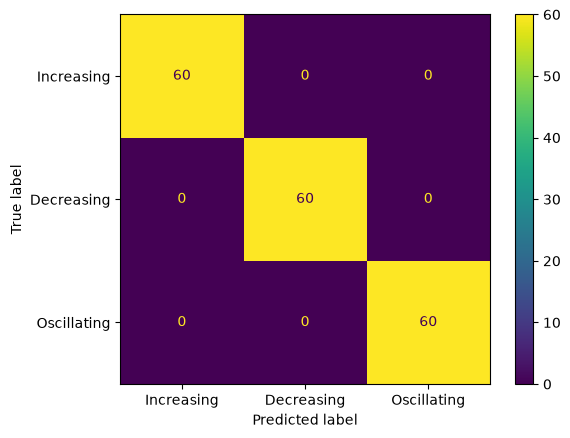

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_cls,
    predictions,
    display_labels=[
        "Increasing",
        "Decreasing",
        "Oscillating"
    ]
)

plt.show()

# Part 3 — Visualize Hidden States

Instead of looking only at the predictions, we'll inspect what the LSTM has learned internally.

## Step 35 — Extract the LSTM Features

In [40]:
feature_model = Model(
    inputs=classifier.inputs,
    outputs=classifier.layers[1].output
)

## Step 36 — Compute Features

In [41]:
hidden_features = feature_model.predict(X_test_cls)

print(hidden_features.shape)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
(180, 32)


## Step 37 — PCA Visualization

In [42]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(hidden_features)

## Step 38 — Scatter Plot

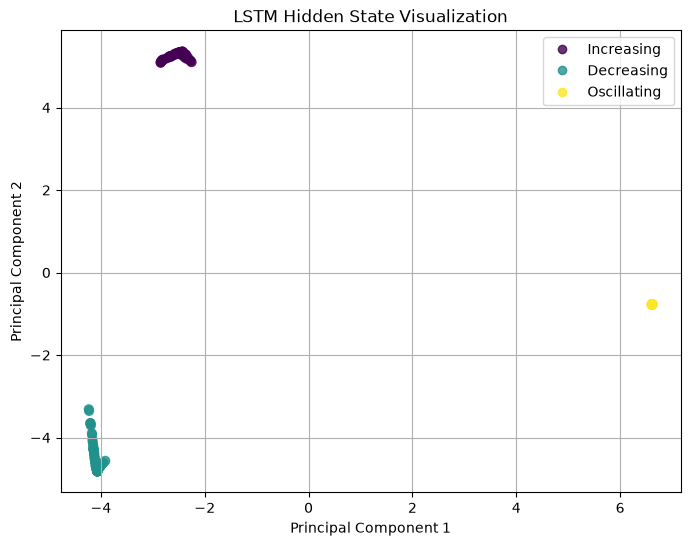

In [44]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=y_test_cls,
    cmap="viridis",
    s=40,
    alpha=0.8
)

plt.title("LSTM Hidden State Visualization")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    handles=scatter.legend_elements()[0],
    labels=[
        "Increasing",
        "Decreasing",
        "Oscillating"
    ]
)

plt.grid(True)

plt.show()

# Summary

In this notebook, we explored sequential models using TensorFlow/Keras.

We learned how to:

- Generate synthetic sequential data
- Convert sequences into supervised learning samples using sliding windows
- Build and train an LSTM for time-series prediction
- Build and compare a GRU model
- Perform sequence pattern classification with an LSTM
- Evaluate classification performance using accuracy, a classification report, and a confusion matrix
- Extract and visualize learned hidden representations using PCA

These experiments demonstrate how recurrent neural networks can model temporal dependencies and learn meaningful representations from sequential data.